# ## Resources

This notebook demonstrates how to build and evaluate a neural network for classifying the **Iris flower dataset** using TensorFlow and Keras.

### Notebook Overview
1.  **Data Preparation**: Loading the Iris dataset, splitting it into training and testing sets, and performing feature scaling using `StandardScaler`.
2.  **Model Architecture**: A multi-layer perceptron (MLP) with three hidden layers and a Softmax output layer for multi-class classification.
3.  **Hyperparameter Tuning**: Iterating through different learning rates and epoch counts to find the optimal configuration.
4.  **Results Visualization**: Plotting training vs. validation accuracy and summarizing the performance across different settings.

### Key Libraries Used
*   **TensorFlow/Keras**: For building and training the deep learning model.
*   **Scikit-learn**: For dataset loading, splitting, and preprocessing.
*   **Matplotlib**: For visualizing training history.

### 1. Imports
We begin by importing the necessary libraries for deep learning (TensorFlow/Keras), data handling (Scikit-learn), and visualization (Matplotlib).

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


### 2. Data Loading and Splitting
We load the Iris dataset and split it into training (80%) and testing (20%) sets to evaluate how our model generalizes to unseen data.

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### 3. Feature Scaling
Neural networks converge faster when features are on a similar scale. We use `StandardScaler` to normalize our input features to have a mean of 0 and variance of 1.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4. Model Definition
We define a function to create a `Sequential` MLP. The architecture consists of multiple hidden layers with ReLU activation and a final layer with Softmax for classification.

In [ ]:
def create_model(learning_rate):
    model=Sequential()
    model.add(Dense(10,activation='relu',input_shape=(4,)))
    model.add(Dense(8,activation='relu'))
    model.add(Dense(5,activation='relu'))
    model.add(Dense(3,activation='softmax'))

    optimizer = SGD(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

### 5. Hyperparameter Setup
We define a range of learning rates and epoch counts to experiment with, allowing us to see how these parameters affect model performance.

In [ ]:
learning_rates=[0.01,0.1,1.0]
epochs_list = [20,50,100]

### 6. Training and Evaluation Loop
This section iterates through all combinations of the defined hyperparameters, trains the model, and stores the results for comparison.

In [ ]:
results = {}

for lr in learning_rates:
    for epochs in epochs_list:
        print(f"\nTraining with Learning Rate={lr}, Epochs={epochs}")

        model = create_model(lr)

        history = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            validation_split=0.2,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        results[(lr, epochs)] = {
            'accuracy': test_acc,
            'history': history.history
        }

        print("Test Accuracy:", round(test_acc, 4))


Training with Learning Rate=0.01, Epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.1

Training with Learning Rate=0.01, Epochs=50
Test Accuracy: 0.9333

Training with Learning Rate=0.01, Epochs=100
Test Accuracy: 0.6333

Training with Learning Rate=0.1, Epochs=20
Test Accuracy: 0.9333

Training with Learning Rate=0.1, Epochs=50
Test Accuracy: 1.0

Training with Learning Rate=0.1, Epochs=100
Test Accuracy: 0.9667

Training with Learning Rate=1.0, Epochs=20
Test Accuracy: 1.0

Training with Learning Rate=1.0, Epochs=50
Test Accuracy: 0.9667

Training with Learning Rate=1.0, Epochs=100
Test Accuracy: 0.9667


### 7. Results Visualization and Summary
Finally, we plot the accuracy curves for a specific run and display a summary table of all experiments to identify the best-performing hyperparameters.

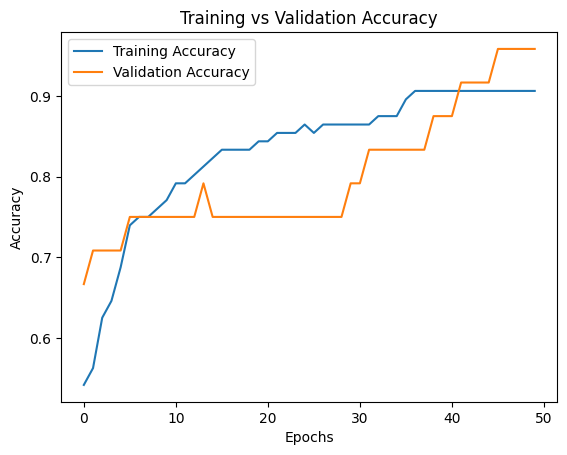


Summary
-------------------------------------------
Learning Rate	Epochs	Test Accuracy
-------------------------------------------
0.01		20	0.1000
0.01		50	0.9333
0.01		100	0.6333
0.1		20	0.9333
0.1		50	1.0000
0.1		100	0.9667
1.0		20	1.0000
1.0		50	0.9667
1.0		100	0.9667


In [ ]:
history = results[(0.01, 50)]['history']

plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

print("\nSummary")
print("-------------------------------------------")
print("Learning Rate\tEpochs\tTest Accuracy")
print("-------------------------------------------")

for key, value in results.items():
    print(f"{key[0]}\t\t{key[1]}\t{value['accuracy']:.4f}")